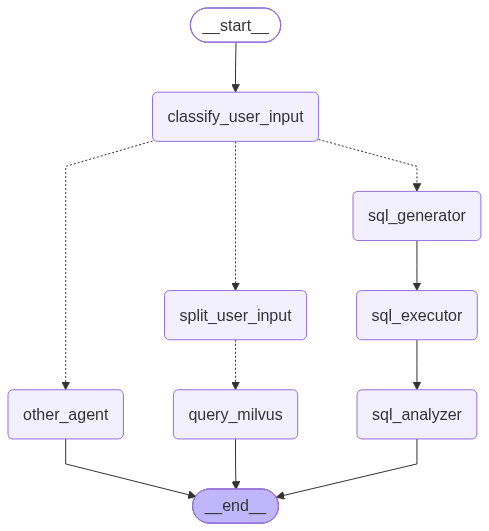

{"classification": "other", "user_input": "给我讲一个超级搞笑的笑话吧"}有个人去面试，面试官问他：“你最大的缺点是什么？”

他想了想，诚恳地说：“太诚实。”

面试官摆摆手说：“我觉得诚实不能算缺点啊，这反而是美德。”

他立刻回道：“我真不在乎你怎么觉得。”

（这个笑话的精髓在于，他用最“诚实”的方式，当场验证了自己的“缺点”，让面试官连反驳的机会都没有。有时候最高级的搞笑不是刻意抖包袱，而是逻辑自洽到让人猝不及防的“真实”。）

In [1]:
from typing import TypedDict, Literal, Annotated, Sequence
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import pymssql

from langchain.messages import HumanMessage, SystemMessage
from services.model_service import ModelService
from services.milvus_service import MilvusService

model_service = ModelService()
# milvus_service = MilvusService()
# milvus_service.connect()

# from loadmodel import load_model

# model = load_model()

model = model_service.load_llm_model()

class InputState(TypedDict):
    """
    输入状态
    """
    user_input: str

class UserInputClassification(TypedDict):
    """
    用户输入分类
    """
    classification: Literal["rag", "sql", "other"]
    user_input: str

class QueryMilvusState(TypedDict):
    """
    查询Milvus状态
    """
    user_input: str

class UserInputSplit(TypedDict):
    """
    用户输入拆分
    """
    user_input_real: str
    user_inputs: list[str]

class OverAllState(TypedDict):
    """
    系统状态
    """
    user_input: str
    classification: UserInputClassification
    user_input_split: UserInputSplit
    milvus_results: Annotated[list[str], add]
    sql_str: str
    sql_results: list[tuple]
    sql_analysis_result: str
    other_results: str


# model = model_service.load_llm_model()

def classify_user_input(state: InputState) -> OverAllState:
    """
    对用户输入进行分类
    """
    user_input = state["user_input"]
    system_content = f"""
        你是一个专业的语义分类助手，只能对用户输入进行分类，不能进行其他操作，分类结果只能是rag、sql或other，
        如果是用户输入的文本是关于药厂制度文件等相关的，分类结果为rag
        如果是用户输入的文本是关于销售采购库存等经营数据相关的，分类结果为sql
        如果是用户输入的文本是关于其他等相关的，分类结果为other
    """
    system_message = SystemMessage(content=system_content)
    human_message = HumanMessage(content=user_input)
    messages = [system_message, human_message]
    
    response = model.with_structured_output(UserInputClassification).invoke(messages)

    return {
        "user_input": user_input,
        "classification": response["classification"]
    }

def split_user_input(state: OverAllState) -> OverAllState:
    """
    对用户输入进行拆分
    """
    user_input = state["user_input"]
    system_content = f"""
        你是一个专业的用户输入拆分助手，
        对用户输入的文本进行分析，并拆分成多个可以用来检索知识库的子文本（10个以内），
        拆分内容必须是与药厂制度文件，药品质量，药品相关法律法规等相关的
        识别出用户输入的真实意图。
    """
    system_message = SystemMessage(content=system_content)
    human_message = HumanMessage(content=user_input)
    messages = [system_message, human_message]
    
    user_input_split = model.with_structured_output(UserInputSplit).invoke(messages)

    return {
        "user_input_split": user_input_split
    }

def rag_router(state: OverAllState) -> Sequence[Send]:
    """
    rag_agent
    """
    user_input_split = state["user_input_split"]
    tasks = []
    if user_input_split["user_inputs"]:
        for index, user_input in enumerate(user_input_split["user_inputs"]):
            task = Send(
                "query_milvus",
                {"user_input": user_input},
            )
            tasks.append(task)
    
    return tasks

def query_milvus(state: QueryMilvusState) -> OverAllState:
    """
    查询Milvus
    """
    user_input = state["user_input"]
    # query_embedding = embedding_service.encode_query(user_input)
    # 从Milvus中查询
    # milvus_results = milvus_service.hybrid_search(
    #     query_text=user_input,
    #     query_embedding=query_embedding,
    #     top_k=recall_top_k
    # )

    milvus_results = f"{user_input}的查询结果。"

    return {
        "milvus_results": [milvus_results]
    }

def sql_generator(state: OverAllState) -> OverAllState:
    """
    生成SQL查询语句
    """
    user_input = state["user_input"]
    system_content = f"""
        你是一个专业的Text2SQL助手，针对用户输入的文本，生成对应的SQL查询语句。
        生成的SQL查询语句必须是正确的MSSQLServer的SQL语法，不能包含任何错误或无效的SQL语句。
        生成的SQL查询语句是关于药厂的物料采购、物料成品库存以及成品销售等数据查询语句。
        查询结果尽量详细。
        数据库表结构如下： 
        商品流水表：splsk,spid:商品内码,rq:日期,dwbh:单位内码,pihao:商品批号,
            djbh:单据编号(JHA开头：采购入库单，JHC开头：采购退出单，JHB开头：采购退补价单，XSA开头：销售出库单，XSC开头：销售退出单，XSB开头：销售退补价单),
            rkshl:入库数量,rkdj:入库单价,rkje:入库金额,chkshl:出库数量,chkje:出库金额,xshe:销售额
        商品货位批号库存表：sphwph,spid:商品内码,pihao:商品批号,shl:库存数量
        商品资料表：spkfk,spid:商品内码,spbh:商品编号,spmch:商品名称,shpgg:商品规格,dw:单位,shpchd:商品产地,shengccj:生产厂家,leibie:商品类型
        采购销售单位表：mchk,dwbh:单位内码,danwbh:单位编号,dwmch:单位名称,ywy:业务员,isjh:是否是采购单位(是，否),isxs:是否是销售单位(是，否),dzhdh:联系地址
    """
    system_message = SystemMessage(content=system_content)
    human_message = HumanMessage(content=user_input)
    messages = [system_message, human_message]
    
    response = model.invoke(messages)

    return {
        "sql_str": response.content.replace("```sql", "").replace("```", "")
    }

def sql_executor(state: OverAllState) -> OverAllState:
    """
    执行SQL查询语句
    """
    sql_str = state["sql_str"]
    sql_results = []
    # 连接数据库，执行SQL查询语句
    conn = pymssql.connect(
        server='208.208.0.252',
        user='sa',
        password='etc12+mdx',
        database='ytzy',
        port=1433,
        tds_version='7.0',  # <--- 关键修改：尝试指定版本
        charset='UTF-8')
    cursor = conn.cursor()
    cursor.execute(sql_str)
    for row in cursor.fetchall():
        sql_results.append(row)
    conn.close()

    return {
        "sql_results": sql_results
    }

def sql_analyzer(state: OverAllState) -> OverAllState:
    """
    分析SQL查询结果
    """
    sql_results = state["sql_results"]
    user_input = state["user_input"]

    # 分析SQL查询结果

    system_content = f"""
        你是一个专业的企业经营数据分析助手。
        针对查询到的业务数据，从药厂角度进行分析。
        从多个维度进行分析，包括但不限于：
        1. 商品销售趋势
        2. 采购销售单位的采购销售趋势
        3. 商品库存趋势
        4. 商品销售金额趋势
        5. 商品销售数量趋势
        分析结果必须是中文。
        分析结果分项分类输出。
    """
    user_content=f"""
        用户的输入内容：{user_input}
        用户查询到的业务数据如下：
        {sql_results}
    """
    
    system_message = SystemMessage(content=system_content)
    human_message = HumanMessage(content=user_content)
    messages = [system_message, human_message]
    response = model.invoke(messages)
    sql_analysis_result = response.content

    return {
        "sql_analysis_result": sql_analysis_result
    }


def other_agent(state: OverAllState) -> OverAllState:
    """
    其他查询
    """
    user_input = state["user_input"]
    result = model.invoke([HumanMessage(content=user_input)])
    return {
        "other_results": result.content
    }


def classification_router(state: OverAllState) -> Literal["split_user_input", "sql_generator", "other_agent"]:
    """
    分类路由
    """
    classification = state["classification"]
    if classification == "rag":
        return "split_user_input"
    elif classification == "sql":
        return "sql_generator"
    else:
        return "other_agent"

builder = StateGraph(state_schema=OverAllState, input_schema=InputState)
builder.add_node("classify_user_input", classify_user_input)    # 对用户输入进行分类
# builder.add_node("rag_agent", rag_agent)                    # rag_agent
builder.add_node("sql_generator", sql_generator)                    # sql_generator
builder.add_node("other_agent", other_agent)                # other_agent
builder.add_node("split_user_input", split_user_input)    # 对用户输入进行拆分
builder.add_node("query_milvus", query_milvus)            # 查询Milvus
builder.add_node("sql_executor", sql_executor)            # 执行SQL查询语句
builder.add_node("sql_analyzer", sql_analyzer)            # 分析SQL查询结果

builder.add_edge(START, "classify_user_input")
builder.add_conditional_edges("classify_user_input", classification_router)
# builder.add_edge("split_user_input", "rag_agent")
# builder.add_edge("rag_agent", "query_milvus")
builder.add_conditional_edges("split_user_input", rag_router, path_map=["query_milvus"])
builder.add_edge("query_milvus", END)
builder.add_edge("sql_generator", "sql_executor")
builder.add_edge("sql_executor", "sql_analyzer")
builder.add_edge("sql_analyzer", END)
builder.add_edge("other_agent", END)

graph = builder.compile()

from IPython.display import display
display(graph)

# user_input = "分析出药厂清洁制度与法律制度不相符的地方"
# user_input = "分析富马酸喹硫平片今年的销售情况"
user_input = "给我讲一个超级搞笑的笑话吧"

for chunk,metadata in graph.stream(
    {"user_input": user_input},
    stream_mode="messages"
    ):
    if chunk.content:
        print(chunk.content, end="", flush=True)

